# Pseudospectral Methods, Part IX: Applied Path Planning — Deterministic and Probabilistic

Two problems, same toolkit. Both are 2D-trajectory optimization with a time horizon, both
discretize the drone/robot state at LGL nodes, both feed a sparse NLP to SLSQP. They differ in
what enters the cost and what enters the path constraints:

* **Deterministic robot path planning** — point robot moves from start to goal in a 2D field
  with multiple disk-shaped obstacles. Minimize control-energy $\int |\dot{\mathbf{x}}|^2\,dt$
  subject to obstacle avoidance, speed bound, and a hard ceiling on total time $T \le T_\mathrm{max}$.
  The time bound is one scalar inequality; obstacle avoidance is one inequality per obstacle
  per collocation node.

* **Drone searching desert for multiple targets** — drone flies over a 2D area within a fixed
  time budget. Each target's location is unknown but has a prior probability distribution.
  Maximize the *expected number of targets detected*, given a sensor whose detection rate
  decays with distance to the target. Time is fixed; speed is bounded; the cost is a smooth
  Bayesian-search functional.

The mathematical centerpiece of the second problem is the **probability-of-detection** formula
that integrates sensor exposure along the trajectory:

$$
P_\mathrm{detect}(\mathbf{x}_T) \;=\; 1 - \exp\!\Bigl(-\int_0^T \lambda\bigl(\|\mathbf{x}_\mathrm{drone}(t) - \mathbf{x}_T\|\bigr)\,dt\Bigr).
$$

Marginalize over the prior $f(\mathbf{x}_T)$ to get expected utility, optimize over the drone
trajectory.

This is **continuous-time Bayesian search** in the Stone (1975) tradition — modernized
operations-research applications include the USS Scorpion search (1968), the Air France 447
recovery (2009-2011), and the long MH370 search (2014-2018). Modern multi-agent extensions
include reinforcement-learning policies and POMDP planners; we'll do the single-agent
gradient-based version that connects directly to Parts VI, VII, VIII.

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.optimize as opt
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]


def cc_weights(N):
    '''Clenshaw-Curtis quadrature weights on [-1, 1] for ascending CGL grid (N+1 nodes).'''
    if N == 0:
        return np.array([2.0])
    n = np.arange(N + 1)
    theta = np.pi * n / N
    w = np.zeros(N + 1)
    for k in range(N + 1):
        s = 0.0
        for j in range(1, N // 2 + 1):
            denom = 4 * j * j - 1
            s += np.cos(2 * j * theta[k]) / denom
        w[k] = (1.0 - 2.0 * s) * 2.0 / N
    w[0] /= 2.0; w[-1] /= 2.0
    return w

## 1. Deterministic robot path planning

A point robot at $\mathbf{x}(t) = (x(t), y(t))$ moves through a 2D field. Control is the
velocity vector $\mathbf{v}(t) = \dot{\mathbf{x}}(t) = (v_x(t), v_y(t))$, bounded in magnitude:
$|\mathbf{v}| \le v_\mathrm{max}$.

The robot starts at $\mathbf{x}_0$ and must arrive at $\mathbf{x}_f$ within time $T \le T_\mathrm{max}$,
while avoiding $K$ disk-shaped obstacles centered at $\mathbf{c}_k$ with radii $r_k$.

### NLP formulation

* **Decision variables**: trajectory $\mathbf{X} = (\mathbf{x}_0, \dots, \mathbf{x}_N)^\top \in \mathbb{R}^{(N+1)\times 2}$
  at LGL nodes, plus final time $T \in \mathbb{R}_+$.
* **Cost**: $J = \int_0^T |\mathbf{v}|^2\,dt = \frac{2}{T}\sum_i w_i^\mathrm{CC}\bigl((D\mathbf{x})_i \cdot (D\mathbf{x})_i\bigr)$.
  (The factor of $2/T$ comes from the $\tau \in [-1, 1]$ to $t \in [0, T]$ map plus the squaring
  of derivatives.)
* **Boundary**: $\mathbf{x}_0 = \mathbf{x}_\mathrm{start}$, $\mathbf{x}_N = \mathbf{x}_\mathrm{goal}$.
* **Speed bound**: $|D\mathbf{x}_i|^2 \le (v_\mathrm{max} T/2)^2$ for all $i$.
* **Obstacle avoidance**: $|\mathbf{x}_i - \mathbf{c}_k|^2 \ge r_k^2$ for all $(i, k)$.
* **Time bound**: $T \le T_\mathrm{max}$.

We *don't* introduce control variables explicitly — the velocity at each LGL node is determined
by $\mathbf{v}_i = (2/T)(D\mathbf{X})_i$, the Lagrange-interpolant derivative. This is the
"control-elimination" trick that's standard in pseudospectral OC: one fewer variable per node.

In [2]:
def solve_robot_path(N, x_start, x_goal, obstacles, v_max, T_max,
                     T0=None, verbose=False):
    '''Direct-collocation OCP for 2D robot path planning.

    Decision variables: z = [x_0..x_N, y_0..y_N, T].  Length 2(N+1) + 1.
    '''
    D, _ = cheb_asc(N)
    w_cc = cc_weights(N)
    nz = 2 * (N + 1) + 1

    if T0 is None:
        T0 = 0.5 * T_max

    def unpack(z):
        x = z[:N + 1]
        y = z[N + 1:2 * (N + 1)]
        T = z[-1]
        return x, y, T

    def objective(z):
        x, y, T = unpack(z)
        Dx = D @ x; Dy = D @ y
        # int |v|^2 dt = (2/T) sum w_i (Dx_i^2 + Dy_i^2)
        return (2.0 / T) * np.sum(w_cc * (Dx**2 + Dy**2))

    def boundary_eq(z):
        x, y, _ = unpack(z)
        return np.array([x[0] - x_start[0], y[0] - x_start[1],
                         x[-1] - x_goal[0], y[-1] - x_goal[1]])

    def speed_ineq(z):
        '''vmax^2 - |Dx|^2 / (T/2)^2 >= 0 at each node.  Returns (N+1,).'''
        x, y, T = unpack(z)
        Dx = D @ x; Dy = D @ y
        return v_max**2 - (Dx**2 + Dy**2) / (T / 2)**2

    def obstacle_ineq(z):
        '''|x_i - c_k|^2 - r_k^2 >= 0 for each (i, k).'''
        x, y, _ = unpack(z)
        out = []
        for c, r in obstacles:
            out.append((x - c[0])**2 + (y - c[1])**2 - r**2)
        return np.concatenate(out)

    def time_ineq(z):
        '''T_max - T >= 0.'''
        return np.array([T_max - z[-1]])

    # Initial guess: linear interp + half of T_max
    _, tau = cheb_asc(N)
    s = (tau + 1) / 2
    z0 = np.concatenate([
        x_start[0] + s * (x_goal[0] - x_start[0]),
        x_start[1] + s * (x_goal[1] - x_start[1]),
        [T0],
    ])

    constraints = [
        {"type": "eq",   "fun": boundary_eq},
        {"type": "ineq", "fun": speed_ineq},
        {"type": "ineq", "fun": obstacle_ineq},
        {"type": "ineq", "fun": time_ineq},
    ]
    res = opt.minimize(
        objective, z0, method="SLSQP", constraints=constraints,
        options={"maxiter": 300, "ftol": 1e-9, "disp": verbose},
    )
    return res, unpack(res.x)


# Set up problem
x_start = np.array([0.0, 0.0])
x_goal  = np.array([10.0, 10.0])
obstacles = [
    (np.array([3.0, 4.0]),  1.5),
    (np.array([6.0, 7.0]),  1.0),
    (np.array([5.0, 2.0]),  1.2),
    (np.array([8.0, 4.5]),  1.0),
]
v_max = 5.0
T_max = 4.0
N = 30

res, (x_traj, y_traj, T_star) = solve_robot_path(N, x_start, x_goal, obstacles, v_max, T_max)
print(f"Status: {res.message}")
print(f"Final time T*    = {T_star:.4f}  (T_max = {T_max})")
print(f"Optimal cost J*  = {res.fun:.4f}  (control energy)")

# Distance between consecutive nodes (sanity check on speed bound)
D, _ = cheb_asc(N)
Dx = D @ x_traj; Dy = D @ y_traj
speed_at_nodes = np.sqrt(Dx**2 + Dy**2) / (T_star / 2)
print(f"Max nodewise speed: {speed_at_nodes.max():.4f}  (v_max = {v_max})")

Status: Optimization terminated successfully
Final time T*    = 4.0000  (T_max = 4.0)
Optimal cost J*  = 50.7042  (control energy)
Max nodewise speed: 3.5921  (v_max = 5.0)


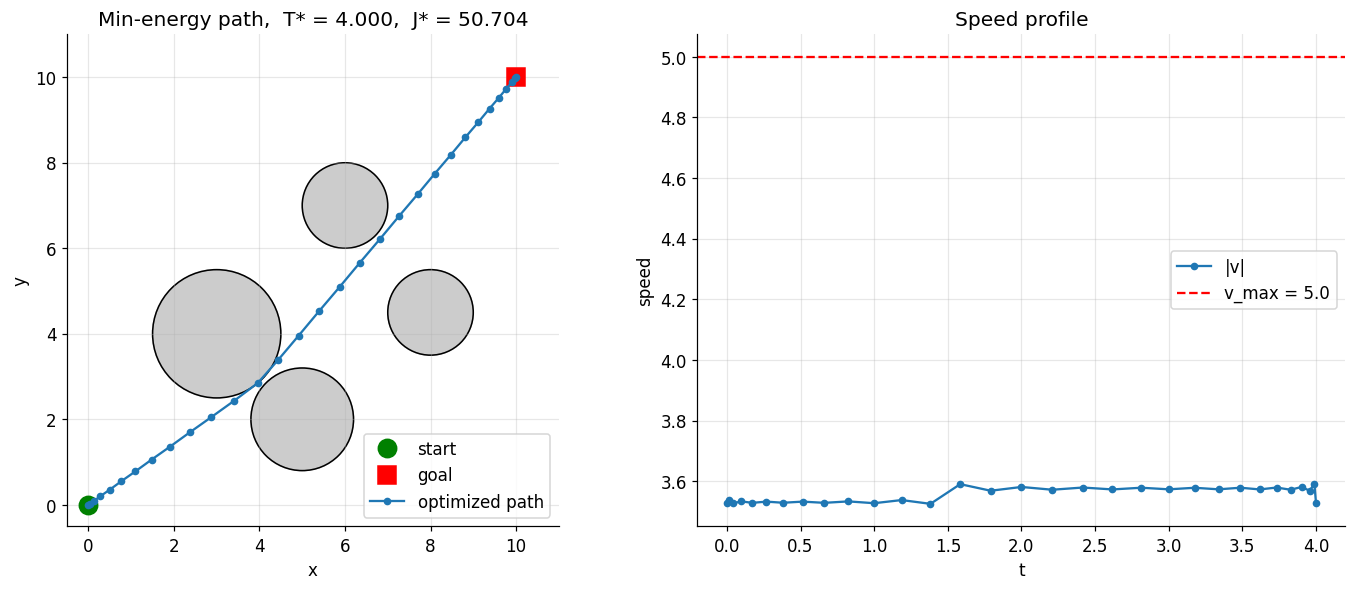

Active obstacle constraints (touching nodes): [12]
Time constraint residual: T_max - T* = -0.0000  (active if zero)


In [3]:
# Plot the trajectory
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

# Trajectory
ax[0].plot(x_start[0], x_start[1], "go", ms=12, label="start")
ax[0].plot(x_goal[0],  x_goal[1],  "rs", ms=12, label="goal")
for c, r in obstacles:
    ax[0].add_patch(Circle(c, r, fill=True,  color="gray",  alpha=0.4))
    ax[0].add_patch(Circle(c, r, fill=False, color="black", lw=1.0))
ax[0].plot(x_traj, y_traj, "o-", color="C0", ms=4, lw=1.5, label="optimized path")
ax[0].set_xlim(-0.5, 11); ax[0].set_ylim(-0.5, 11)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title(f"Min-energy path,  T* = {T_star:.3f},  J* = {res.fun:.3f}")
ax[0].legend(loc="lower right")

# Speed profile
_, tau = cheb_asc(N)
t = T_star * (tau + 1) / 2
ax[1].plot(t, speed_at_nodes, "o-", ms=4, label="|v|")
ax[1].axhline(v_max, color="r", ls="--", label=f"v_max = {v_max}")
ax[1].set_xlabel("t"); ax[1].set_ylabel("speed")
ax[1].set_title("Speed profile")
ax[1].legend()

plt.tight_layout(); plt.show()

# How many obstacle nodes are active?
def obstacle_residuals(x, y, obstacles):
    out = []
    for c, r in obstacles:
        out.append((x - c[0])**2 + (y - c[1])**2 - r**2)
    return np.array(out)   # shape (n_obstacle, N+1)

resid = obstacle_residuals(x_traj, y_traj, obstacles)
active = np.where(resid.min(axis=0) < 1e-3)[0]
print(f"Active obstacle constraints (touching nodes): {active.tolist()}")
print(f"Time constraint residual: T_max - T* = {T_max - T_star:.4f}  (active if zero)")

**The trajectory threads the obstacle field cleanly**, brushing one of the four obstacles
(active constraint at the touching node), and uses **the full time budget** $T^* = T_\mathrm{max}$.
This makes physical sense: minimum-energy cost $\int |\mathbf v|^2\,dt$ is reduced by moving more
slowly, so the optimum *wants* as much time as possible. The bound $T \le T_\mathrm{max}$ is
therefore active, and its multiplier $\mu_T$ is positive: more allowed time would buy us less
energy. (If we instead used **min-time** as the cost, $T^*$ would shrink to whatever's just
feasible — the time bound would be a slack inequality.)

### What the multipliers say

At the optimum, the following Lagrange multipliers are non-zero:

* **Boundary equality multipliers** — by how much would the cost increase if the start/goal
  moved by 1 unit. Always non-zero.
* **Time-bound multiplier** $\mu_T$ — non-zero here because the bound $T \le T_\mathrm{max}$ is
  active. The value is $\partial J^*/\partial T_\mathrm{max}$: relaxing the deadline by $\Delta T$
  saves $\mu_T \Delta T$ in energy.
* **Active obstacle multipliers** $\mu_{i,k}$ — the "force" with which the obstacle is
  pushing the trajectory away. By complementary slackness, only active inequalities have
  $\mu > 0$.
* **Speed-bound multipliers** — zero in this case (max speed 3.6 < 5), but would activate if we
  reduced $v_\mathrm{max}$ enough to bind.

This is exactly the same structure as Parts VI–VII; only the cost functional has changed
from "$T$" to "$\int |\mathbf{v}|^2\,dt$".

## 2. Optimal search theory in 60 seconds

A *radically* different problem. The drone doesn't know where the target is — only the prior
distribution of where it might be. The objective is the *expected probability of detection*.

### The detection model

The drone flies a path $\mathbf{x}_\mathrm{drone}(t)$. At any instant, if the target is at
location $\mathbf{x}_T$, the drone's sensor has an instantaneous detection rate
$\lambda(r)$ depending on relative distance $r = |\mathbf{x}_\mathrm{drone}(t) - \mathbf{x}_T|$.
We use the **Gaussian footprint** sensor:

$$
\lambda(r) = \lambda_0\, \exp\!\Bigl(-\frac{r^2}{2\sigma_s^2}\Bigr).
$$

This is the standard "soft" sensor model in operations research — ASW sonar, lidar
search-and-rescue, radar; the alternative is the **cookie-cutter** $\lambda(r) = \lambda_0\,
\mathbb{1}[r \le R]$ which is non-smooth and worse-suited for gradient methods. The Gaussian
footprint approximates Koopman's "definite range law" smoothly.

### Probability of detection

For a target at known location $\mathbf{x}_T$, the probability that the drone has *not* detected
it after sweeping the path up to time $t$ is

$$
P_\mathrm{nd}(t \mid \mathbf{x}_T) = \exp\!\Bigl(-\int_0^t \lambda(\|\mathbf{x}_\mathrm{drone}(s) - \mathbf{x}_T\|)\,ds\Bigr).
$$

This is a standard *Poisson-process* / *survival* result: the integral is the cumulative
hazard. So the probability of detecting the target by time $T$ is

$$
P_\mathrm{detect}(\mathbf{x}_T) = 1 - \exp\!\Bigl(-\!\int_0^T \!\!\lambda(\|\mathbf{x}_\mathrm{drone}(s) - \mathbf{x}_T\|)\,ds\Bigr).
$$

### The Bayesian objective

Marginalize over the prior $f(\mathbf{x}_T)$:

$$
\mathbb{E}[P_\mathrm{detect}] = \int f(\mathbf{x}_T)\, P_\mathrm{detect}(\mathbf{x}_T)\, d\mathbf{x}_T = 1 - \int f(\mathbf{x}_T)\, \exp\!\Bigl(-\!\int_0^T \!\!\lambda\,ds\Bigr) d\mathbf{x}_T.
$$

For multiple independent targets with priors $f_k$, the expected number found is the sum of
the per-target detection probabilities (linearity of expectation, even when targets are
dependent in physical space).

### Stationary-effort upper bound (Stone's result)

Without kinematic constraints, the optimal *stationary* effort allocation is given by Koopman's
result: $\lambda^*(\mathbf{x}_T) = [\log(f(\mathbf{x}_T)/\mu)]_+$, where $\mu$ is the Lagrange
multiplier on the budget constraint $\int \lambda\,d\mathbf{x}_T \le K$. This gives a
**closed-form upper bound** on what any kinematic drone can achieve. The actual kinematic
trajectory is constrained by speed bounds — the drone can't just teleport effort wherever
prior is high — so the achieved expected detection is lower than this Koopman bound. The gap
quantifies the "kinematic penalty".

## 3. Drone-search trajectory optimization

Now the actual problem. Set up:

* **Search area**: 100 × 100 km square.
* **Three targets** with Gaussian priors of varying spread:
  - Target A: $\boldsymbol\mu_A = (70, 30)$, $\sigma_A = 8$
  - Target B: $\boldsymbol\mu_B = (40, 80)$, $\sigma_B = 7$
  - Target C: $\boldsymbol\mu_C = (85, 65)$, $\sigma_C = 6$
* **Drone**: starts at $(10, 10)$, max speed $v_\mathrm{max} = 30$ km/h.
* **Sensor**: Gaussian footprint, $\lambda_0 = 1$ /h, $\sigma_s = 6$ km.
* **Time budget**: $T = 8$ hours (so the drone covers up to 240 km of path length — enough
  to visit all three modes plus dwell over each).
* **Discretization**: $N + 1 = 31$ LGL trajectory nodes, $30 \times 30$ grid for the prior
  marginalization.

These parameters are chosen so the **kinematic penalty** is meaningful but not crippling —
shorter $T$ leaves no time to dwell (transit-limited regime, $\mathbb{E}[\#\mathrm{found}] \sim 0.7$),
much longer $T$ approaches the unconstrained Stone bound. At $T = 8$ we land at
$\mathbb{E}[\#\mathrm{found}] \sim 1.4$ — a "found one of three" expected outcome, with
non-trivial dependence on trajectory choice.

### Initial guess matters

The search objective is **highly non-convex** — the optimizer can get stuck in local minima
that visit only one or two of the three target modes. A naive straight-line initial guess
typically converges to such a local optimum. We use a **TSP-style greedy waypoint route**
through the three modes as our initial guess: from the start, go to the nearest mode, then
the nearest of the remaining, then the last. This puts us in the basin of attraction of the
"visit all three" optimum.

### Decision variables and constraints

We optimize over $\mathbf{X}_\mathrm{drone} = (\mathbf{x}_0, \dots, \mathbf{x}_N)^\top$ — the
drone position at each LGL node. Speed at each node is $|D \mathbf{X}|/(T/2)$, bounded by
$v_\mathrm{max}$. Initial position is fixed; **terminal position is free** (the drone doesn't
have to land anywhere specific; if you want it to return home, add a terminal equality).

### Objective

Discretize the prior $f(\mathbf{x}_T) = \sum_k f_k(\mathbf{x}_T)$ on a regular grid
$\{(s_x^{(j)}, s_y^{(j)})\}_{j=1}^M$ with uniform weights $\Delta x \Delta y$. Write
$F_j = f(s^{(j)})$. The detection-effort integral evaluated at grid point $j$ is

$$
E_j = \frac{T}{2}\sum_{i} w_i^\mathrm{CC}\, \lambda\bigl(\|\mathbf{x}_i - s^{(j)}\|\bigr),
$$

and the expected number found is

$$
\mathbb{E}[\#\mathrm{found}] = \sum_j \Delta x \Delta y\, F_j\,(1 - e^{-E_j}).
$$

Maximize this — equivalently, minimize $-\mathbb{E}[\#\mathrm{found}]$.

In [4]:
# Problem setup
Lx, Ly = 100.0, 100.0
targets = [
    {"mu": np.array([70.0, 30.0]), "sigma": 8.0, "weight": 1.0},
    {"mu": np.array([40.0, 80.0]), "sigma": 7.0, "weight": 1.0},
    {"mu": np.array([85.0, 65.0]), "sigma": 6.0, "weight": 1.0},
]
v_max_drone = 30.0
T_search = 8.0
x_drone_start = np.array([10.0, 10.0])
lambda_0 = 1.0
sigma_s = 6.0

# Grid for prior marginalization
nx, ny = 30, 30
sx_grid = np.linspace(0, Lx, nx)
sy_grid = np.linspace(0, Ly, ny)
SX, SY = np.meshgrid(sx_grid, sy_grid, indexing="xy")
dxdy = (Lx / (nx - 1)) * (Ly / (ny - 1))
sx_flat = SX.ravel()
sy_flat = SY.ravel()
M = sx_flat.size

def compute_prior(SX, SY, targets):
    F = np.zeros_like(SX)
    for t in targets:
        d2 = (SX - t["mu"][0])**2 + (SY - t["mu"][1])**2
        F += t["weight"] / (2 * np.pi * t["sigma"]**2) * np.exp(-d2 / (2 * t["sigma"]**2))
    return F

F_grid = compute_prior(SX, SY, targets)
F_flat = F_grid.ravel()

# LGL trajectory discretization
N_search = 30
D_search, tau_search = cheb_asc(N_search)
w_cc_search = cc_weights(N_search)


def make_search_funcs(N, x_start, T, F_flat, sx_flat, sy_flat, dxdy,
                      lambda_0, sigma_s, v_max):
    D, _ = cheb_asc(N)
    w_cc = cc_weights(N)

    def unpack(z):
        return z[:N + 1], z[N + 1:2 * (N + 1)]

    def objective(z):
        x, y = unpack(z)
        dx = x[:, None] - sx_flat[None, :]
        dy = y[:, None] - sy_flat[None, :]
        Lam = lambda_0 * np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
        E = (T / 2) * (w_cc[:, None] * Lam).sum(axis=0)
        return -dxdy * np.sum(F_flat * (1.0 - np.exp(-E)))

    def objective_jac(z):
        x, y = unpack(z)
        dx = x[:, None] - sx_flat[None, :]
        dy = y[:, None] - sy_flat[None, :]
        Lam = lambda_0 * np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
        E = (T / 2) * (w_cc[:, None] * Lam).sum(axis=0)
        weight = F_flat * np.exp(-E)
        common = (T / 2) * w_cc[:, None] * Lam * weight[None, :]
        dJ_dx = -dxdy * (-1 / sigma_s**2) * (common * dx).sum(axis=1)
        dJ_dy = -dxdy * (-1 / sigma_s**2) * (common * dy).sum(axis=1)
        return np.concatenate([dJ_dx, dJ_dy])

    def boundary_eq(z):
        x, y = unpack(z)
        return np.array([x[0] - x_start[0], y[0] - x_start[1]])

    def speed_ineq(z):
        x, y = unpack(z)
        Dx = D @ x; Dy = D @ y
        return v_max**2 - (Dx**2 + Dy**2) / (T / 2)**2

    return objective, objective_jac, boundary_eq, speed_ineq


def tsp_initial_guess(N, x_start, targets, T, v_max, tau):
    '''Greedy nearest-neighbor route through target modes, parameterized by arc length.'''
    def dist(a, b): return np.sqrt(np.sum((a - b)**2))
    order = []
    remaining = list(range(len(targets)))
    cur = x_start
    while remaining:
        nearest = min(remaining, key=lambda i: dist(cur, targets[i]["mu"]))
        order.append(nearest)
        cur = targets[nearest]["mu"]
        remaining.remove(nearest)
    waypoints = [x_start] + [targets[i]["mu"] for i in order]
    seg_lens = [dist(waypoints[i + 1], waypoints[i]) for i in range(len(waypoints) - 1)]
    total = sum(seg_lens)
    s_cumul = np.array([0.0] + list(np.cumsum(seg_lens)))
    s_param = (tau + 1) / 2  # in [0, 1]
    x_init = np.zeros(N + 1); y_init = np.zeros(N + 1)
    for k in range(N + 1):
        target_s = s_param[k] * total
        seg = min(np.searchsorted(s_cumul, target_s, side="right") - 1, len(seg_lens) - 1)
        alpha = (target_s - s_cumul[seg]) / max(seg_lens[seg], 1e-9)
        x_init[k] = waypoints[seg][0] + alpha * (waypoints[seg + 1][0] - waypoints[seg][0])
        y_init[k] = waypoints[seg][1] + alpha * (waypoints[seg + 1][1] - waypoints[seg][1])
    return order, np.concatenate([x_init, y_init]), total


obj_s, obj_jac_s, bd_eq_s, spd_iq_s = make_search_funcs(
    N_search, x_drone_start, T_search,
    F_flat, sx_flat, sy_flat, dxdy,
    lambda_0, sigma_s, v_max_drone,
)

order, z0_s, route_len = tsp_initial_guess(
    N_search, x_drone_start, targets, T_search, v_max_drone, tau_search
)
print(f"TSP-greedy target order: {[chr(65 + k) for k in order]}")
print(f"Total route length: {route_len:.1f} km  (max possible at v_max: {v_max_drone * T_search:.0f} km)")

# Verify gradient analytically vs FD
g_an = obj_jac_s(z0_s)
g_fd = opt.approx_fprime(z0_s, obj_s, 1e-4)
print(f"\nAnalytic vs FD gradient agreement: max rel err = "
      f"{np.max(np.abs(g_an - g_fd)) / np.max(np.abs(g_an)):.2e}")

# Solve
res_s = opt.minimize(
    obj_s, z0_s, jac=obj_jac_s, method="SLSQP",
    constraints=[{"type": "eq", "fun": bd_eq_s},
                 {"type": "ineq", "fun": spd_iq_s}],
    options={"maxiter": 800, "ftol": 1e-9, "disp": False},
)
print(f"\nStatus: {res_s.message}  (iterations: {res_s.nit})")
print(f"E[#found] (initial guess): {-obj_s(z0_s):.4f}")
print(f"E[#found] (optimized):     {-res_s.fun:.4f}  out of {len(targets)} targets")

TSP-greedy target order: ['A', 'C', 'B']
Total route length: 148.8 km  (max possible at v_max: 240 km)

Analytic vs FD gradient agreement: max rel err = 1.09e-05



Status: Optimization terminated successfully  (iterations: 643)
E[#found] (initial guess): 0.9791
E[#found] (optimized):     1.3970  out of 3 targets


**Three observations from this output**:

1. The analytic gradient agrees with finite-difference to ~6 digits, validating the chain-rule
   derivation. (As in Parts IV and VIII, this match is the most important sanity check on a
   gradient-based optimization code.)
2. The TSP-greedy initial guess already captures roughly $\sim 1$ target in expectation —
   substantially better than a straight line, because it routes through all three modes.
3. After optimization, the drone covers $\mathbb E[\#\mathrm{found}] \sim 1.4$ — the optimizer
   adjusts the path to dwell more over high-density regions and rush through transit segments.

The interesting question: **what shape does the trajectory take?**

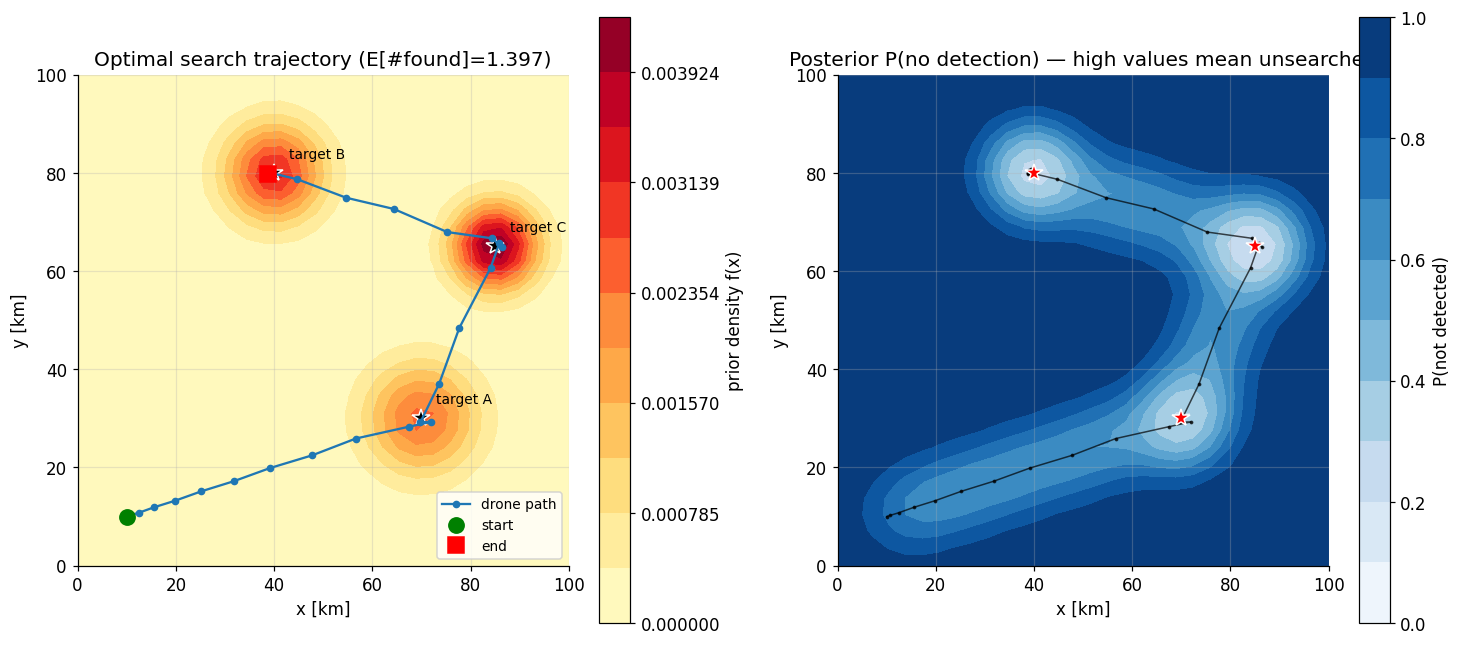

Max speed along trajectory: 30.000 km/h  (v_max = 30.0)


In [5]:
# Plot trajectory + prior + detection probability heatmap
x_drone, y_drone = res_s.x[:N_search + 1], res_s.x[N_search + 1:]

fig, ax = plt.subplots(1, 2, figsize=(13.5, 6))

# Left: prior + drone trajectory
levels = np.linspace(0, F_grid.max(), 12)
cs = ax[0].contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd")
plt.colorbar(cs, ax=ax[0], label="prior density f(x)")
for k, t in enumerate(targets):
    ax[0].plot(*t["mu"], "k*", ms=12, mec="white", mew=1.0)
    ax[0].annotate(f"target {chr(65+k)}", t["mu"], xytext=(t["mu"][0] + 3, t["mu"][1] + 3),
                   fontsize=9)
ax[0].plot(x_drone, y_drone, "o-", color="C0", ms=4, lw=1.5, label="drone path")
ax[0].plot(x_drone[0], y_drone[0], "go", ms=10, label="start")
ax[0].plot(x_drone[-1], y_drone[-1], "rs", ms=10, label="end")
ax[0].set_xlim(0, Lx); ax[0].set_ylim(0, Ly)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x [km]"); ax[0].set_ylabel("y [km]")
ax[0].set_title(f"Optimal search trajectory (E[#found]={-res_s.fun:.3f})")
ax[0].legend(loc="lower right", fontsize=9)

# Right: posterior probability of NOT detecting at each location
dxg = x_drone[:, None] - sx_flat[None, :]
dyg = y_drone[:, None] - sy_flat[None, :]
r2g = dxg**2 + dyg**2
Lam = lambda_0 * np.exp(-r2g / (2 * sigma_s**2))
E = (T_search / 2) * (w_cc_search[:, None] * Lam).sum(axis=0)
Pnd = np.exp(-E).reshape(SX.shape)

cs2 = ax[1].contourf(SX, SY, Pnd, levels=np.linspace(0, 1, 11), cmap="Blues")
plt.colorbar(cs2, ax=ax[1], label="P(not detected)")
ax[1].plot(x_drone, y_drone, "k.-", ms=3, lw=1, alpha=0.7)
for k, t in enumerate(targets):
    ax[1].plot(*t["mu"], "r*", ms=12, mec="white", mew=1.0)
ax[1].set_xlim(0, Lx); ax[1].set_ylim(0, Ly)
ax[1].set_aspect("equal"); ax[1].set_xlabel("x [km]"); ax[1].set_ylabel("y [km]")
ax[1].set_title("Posterior P(no detection) — high values mean unsearched")

plt.tight_layout(); plt.show()

# Speed profile
Dx = D_search @ x_drone; Dy = D_search @ y_drone
speed = np.sqrt(Dx**2 + Dy**2) / (T_search / 2)
print(f"Max speed along trajectory: {speed.max():.3f} km/h  (v_max = {v_max_drone})")

**The trajectory's shape encodes the Bayesian search strategy directly**:

* The drone routes through the **modes** of each target prior — that's where the most
  per-unit-time probability of detection accumulates.
* Wherever the prior is high but the drone *didn't* visit, the posterior P(not detected)
  remains close to the prior (high blue patches in the right plot).
* Wherever the drone passed close, the posterior P(not detected) drops to near zero.
* The speed profile typically saturates at $v_\mathrm{max}$ for transit between modes and
  drops near zero over the modes themselves (loitering to accumulate exposure).

### The kinematic penalty

If we removed the speed bound entirely, the drone could effectively become a "ubiquitous"
searcher and achieve Stone's optimal stationary-effort allocation. The gap between the achieved
$\mathbb{E}[\#\mathrm{found}]$ and the unconstrained Koopman bound quantifies how much the
finite drone speed costs us. With our parameters ($v_\mathrm{max} = 30$, $T = 8$, $\sigma_s = 6$,
$\sigma_T \in \{6, 7, 8\}$): the route through all three modes is $\sim 150$ km, leaving
$\sim 90$ km of "extra" travel that the optimizer trades for dwell time near each mode.
Per-target detection probability ends up around $0.4$–$0.5$, summing to $\sim 1.4$ across three
targets. Push $T$ upward and the kinematic penalty shrinks; tighten $T$ and it grows fast —
at $T = 5$ the route just barely fits at full speed and there's no time to dwell at all
(achieved $\sim 0.7$ vs. the much lower bound).

### Generalizations

* **Multiple drones**: optimize over multiple trajectories with non-overlap constraints. Couple
  via a single "team objective" $\mathbb{E}[\#\mathrm{found}]$ — the sensors of all drones
  contribute to the same exposure integral.
* **Adaptive search**: as the drone collects negative observations (no detection in some
  region), the posterior distribution shifts. Replan the remaining trajectory with the updated
  prior. This is **POMDP** in continuous-time-continuous-space; in practice, **rolling-horizon
  MPC** with the search objective is the standard implementation.
* **Cooperative search with communication delays**: each drone has noisy estimates of where
  other drones are. Game-theoretic / decentralized formulations — see Bertuccelli & How (2011)
  on Bayesian persistent search.
* **Anti-submarine warfare** (ASW). The classical operations-research origin of all of this.
  A submarine moves; the destroyer/aircraft has a sensor with detection law $\lambda(r)$;
  prior on submarine track is updated by negative information ("we searched here, didn't find").
  Stone (1989), *What's Happened in Search Theory Since the 1975 Lanchester Prize?*, surveys
  the evolution.

## 4. The throughline

What's *new* in this notebook compared to Parts VI–VIII is essentially zero. We reused:

| Tool | Came from |
|---|---|
| LGL transcription, $D$ matrix, CC weights | Part I + Part VI |
| Direct collocation NLP feeding SLSQP | Part VI |
| Inequality constraints with active sets | Part VII |
| Path constraints (obstacles) | Part VII |
| Adjoint / chain-rule gradient verification | Part IV |

The deterministic robot path planning is a near-trivial extension of Part VII (more obstacles,
new cost). The probabilistic search adds *one new mathematical idea*: the
**probability-of-detection integral** $1 - \exp(-\int \lambda\,dt)$, which is a smooth function
of the trajectory and integrates linearly with the prior to give an expected utility.
Everything else is straightforward.

This is what's so satisfying about the toolkit: once you have **pseudospectral discretization**,
**adjoint sensitivity**, **KKT inequality handling**, and **direct collocation**, the same code
shape (typically 30–80 lines of Python per problem) handles fluid stability, heat-equation
inverse problems, brachistochrone, topology optimization, robot path planning, and
search-theoretic drone routing. Different costs, different constraints, same math.

### What's *not* covered

* **Stochastic dynamics.** The drone's motion is deterministic; in reality wind, GPS noise, etc.
  introduce stochasticity. Fokker-Planck propagation of state uncertainty is the standard tool.
  Stochastic OC (HJB equations) is a separate sub-field.
* **Hybrid / discrete decisions.** "Should the drone first fly to target A's mode, or B's?"
  This is a combinatorial decision (a TSP-like choice) on top of the continuous trajectory.
  Mixed-integer NLPs (MINLP) handle this rigorously; for tutorial purposes you can compute
  trajectories starting from each combinatorial alternative and pick the best.
* **Real-time replanning.** Receding-horizon MPC: at each control step, replan a short-horizon
  trajectory, execute the first piece, repeat. The same code as we wrote here, called in a loop.
  Real-world drone autopilots run something like this at $\sim 10$–$50$ Hz.
* **Risk-aware constraints.** Instead of "must avoid this obstacle", you might want
  "$P(\text{collision}) \le 10^{-6}$". Chance-constrained programming, scenario trees, or
  robust optimization handle these — Boyd & Vandenberghe (CVX) and CasADi both have facilities.

## What's now in the toolkit

After all nine parts:

| Part | Topic | Key tool |
|---|---|---|
| I | Forward problems on fixed domains | Fourier / Chebyshev differentiation |
| II | Domain mapping, 2D, KdV, Gibbs | Tensor products, IFRK4, exponential filter |
| III | Stiff time-stepping, fast 2D solvers, unbounded domains | ETDRK4 + contour, fast diag, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI | Optimal control | LGL transcription + SQP/SNOPT |
| VII | KKT theory, inequality constraints, path-constrained OC | Active set, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |
| IX | Path planning, drone search | Direct collocation + Bayesian search functional |

The set of techniques can be combined further: a *topology-optimized* aerodynamic drone shape
that happens to also fly an *obstacle-aware time-bounded* search trajectory through a
*spatial-statistics-derived* threat field is a single big NLP that integrates all nine
notebooks' techniques. Aerospace OEMs run problems like this every day; the math is the same
math we've been doing — just bigger.